# Level 3 - Task 2: Customer Preference Analysis

## Objective

Analyze customer preferences in the Zomato dataset by studying the
relationship between restaurant ratings, votes, cuisines, price range,
online delivery, and table booking.

### Analysis Areas

- Relationship between ratings and votes
- Popular cuisines based on customer preferences
- Price range and customer preferences
- Online delivery preferences
- Table booking preferences
- Restaurant rating patterns

### Expected Outcome

Identify important customer preference patterns and factors associated
with restaurant popularity and ratings.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:


df = pd.read_csv("Outputs/feature_engineered_zomato.csv")

print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nRelevant Columns:")
relevant_columns = [
    "Restaurant Name",
    "Cuisines",
    "Aggregate rating",
    "Votes",
    "Price range",
    "City"
]

print([col for col in relevant_columns if col in df.columns])

print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape: (9551, 27)

Columns:
['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Rating color', 'Rating text', 'Votes', 'Restaurant Name Length', 'Address Length', 'Has Table Booking Encoded', 'Has Online Delivery Encoded', 'Price Range Category', 'Log Votes']

Relevant Columns:
['Restaurant Name', 'Cuisines', 'Aggregate rating', 'Votes', 'Price range', 'City']

First 5 Rows:


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Aggregate rating,Rating color,Rating text,Votes,Restaurant Name Length,Address Length,Has Table Booking Encoded,Has Online Delivery Encoded,Price Range Category,Log Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,4.8,Dark Green,Excellent,314,16,71,1,0,High,5.752573
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,4.5,Dark Green,Excellent,591,16,67,1,0,High,6.383507
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,4.4,Green,Very Good,270,22,56,1,0,Very High,5.602119
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,4.9,Dark Green,Excellent,365,4,70,0,0,Very High,5.902633
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,4.8,Dark Green,Excellent,229,11,64,1,0,Very High,5.438079


In [4]:
#  CHECK AND PREPARE CUISINE DATA
# ==========================================================

print("Missing values in Cuisines:", df["Cuisines"].isnull().sum())

# Remove rows where cuisine information is missing
df = df.dropna(subset=["Cuisines"]).copy()

# Clean cuisine names
df["Cuisines"] = df["Cuisines"].str.strip()

# Check result
print("\nDataset Shape after cleaning:", df.shape)

print("\nSample Cuisine Values:")
print(df["Cuisines"].head(10).to_string(index=False))

print("\nUnique Cuisine Entries:", df["Cuisines"].nunique())

Missing values in Cuisines: 0

Dataset Shape after cleaning: (9551, 27)

Sample Cuisine Values:
        French, Japanese, Desserts
                          Japanese
  Seafood, Asian, Filipino, Indian
                   Japanese, Sushi
                  Japanese, Korean
                           Chinese
                   Asian, European
Seafood, Filipino, Asian, European
           European, Asian, Indian
                          Filipino

Unique Cuisine Entries: 1825


In [5]:
# CUISINE TYPE VS AVERAGE RESTAURANT RATING
# ==========================================================

cuisine_rating = (
    df.groupby("Cuisines")
      .agg(
          Average_Rating=("Aggregate rating", "mean"),
          Restaurant_Count=("Restaurant Name", "count"),
          Total_Votes=("Votes", "sum")
      )
      .reset_index()
)

# Sort by average rating
cuisine_rating = cuisine_rating.sort_values(
    by="Average_Rating",
    ascending=False
)

print("Cuisine Rating Analysis:")
display(cuisine_rating.head(20))

Cuisine Rating Analysis:


,Cuisines,Average_Rating,Restaurant_Count,Total_Votes
302,"Burger, Bar Food, Steak",4.90,1,2238
33,"American, Burger, Grill",4.90,1,162
37,"American, Caribbean, Seafood",4.90,1,548
41,"American, Coffee and Tea",4.90,1,570
1214,"Mexican, American, Healthy Food",4.90,1,223
1034,"Italian, Bakery, Continental",4.90,1,322
169,"BBQ, Breakfast, Southern",4.90,1,249
808,"European, German",4.90,1,1413
949,"Hawaiian, Seafood",4.90,1,1343
1779,"Sunda, Indonesian",4.90,3,5514


In [6]:
# MOST POPULAR CUISINES BASED ON VOTES
# ==========================================================

cuisine_votes = (
    df.groupby("Cuisines")
      .agg(
          Total_Votes=("Votes", "sum"),
          Restaurant_Count=("Restaurant Name", "count"),
          Average_Rating=("Aggregate rating", "mean")
      )
      .reset_index()
)

# Sort cuisines by total votes
cuisine_votes = cuisine_votes.sort_values(
    by="Total_Votes",
    ascending=False
)

print("Top 20 Most Popular Cuisines Based on Total Votes:")
display(cuisine_votes.head(20))

Top 20 Most Popular Cuisines Based on Total Votes:


,Cuisines,Total_Votes,Restaurant_Count,Average_Rating
1514,"North Indian, Mughlai",53747,334,2.888623
1306,North Indian,48967,945,1.693228
1329,"North Indian, Chinese",42012,511,2.421722
331,Cafe,30657,299,2.890970
497,Chinese,21925,354,2.042090
1520,"North Indian, Mughlai, Chinese",20115,197,2.568528
828,Fast Food,17852,354,2.118362
1699,South Indian,16433,112,2.370536
1288,"Mughlai, North Indian",15275,60,2.091667
1031,Italian,14799,54,3.657407


In [7]:
#  HIGHEST-RATED CUISINES
# ==========================================================

# Keep cuisines with at least 20 restaurants
reliable_cuisines = cuisine_rating[
    cuisine_rating["Restaurant_Count"] >= 20
].copy()

# Sort by average rating
reliable_cuisines = reliable_cuisines.sort_values(
    by="Average_Rating",
    ascending=False
)

print("Highest-Rated Cuisines (Minimum 20 Restaurants):")
display(reliable_cuisines.head(20))

Highest-Rated Cuisines (Minimum 20 Restaurants):


,Cuisines,Average_Rating,Restaurant_Count,Total_Votes
6,American,3.667742,31,7802
1031,Italian,3.657407,54,14799
1098,"Italian, Pizza",3.637500,24,5828
1212,Mexican,3.636111,36,7193
625,Continental,3.566667,21,3455
837,"Fast Food, Burger",3.403571,56,7189
487,"Cafe, Tea",3.375000,20,2532
191,"Bakery, Desserts, Fast Food",3.366667,63,8775
54,"American, Fast Food",3.350000,20,6708
588,"Chinese, Thai",3.309804,51,12354


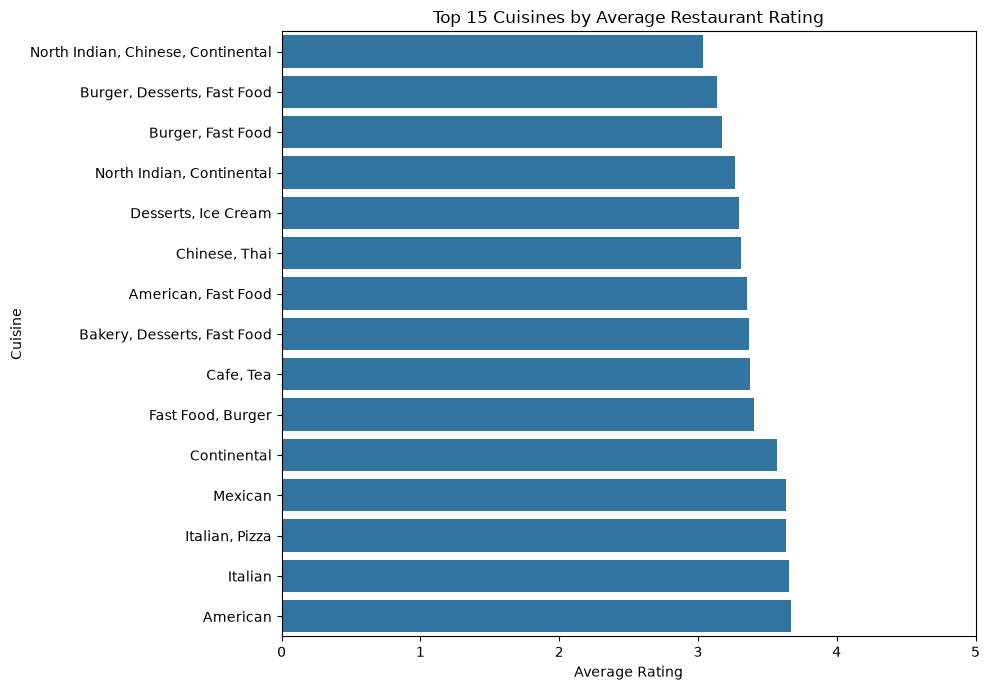

In [8]:
#  VISUALIZE AVERAGE RATING BY CUISINE
# ==========================================================

top_rated_cuisines = reliable_cuisines.head(15).sort_values(
    by="Average_Rating"
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_rated_cuisines,
    x="Average_Rating",
    y="Cuisines"
)

plt.title("Top 15 Cuisines by Average Restaurant Rating")
plt.xlabel("Average Rating")
plt.ylabel("Cuisine")
plt.xlim(0, 5)
plt.tight_layout()
plt.show()

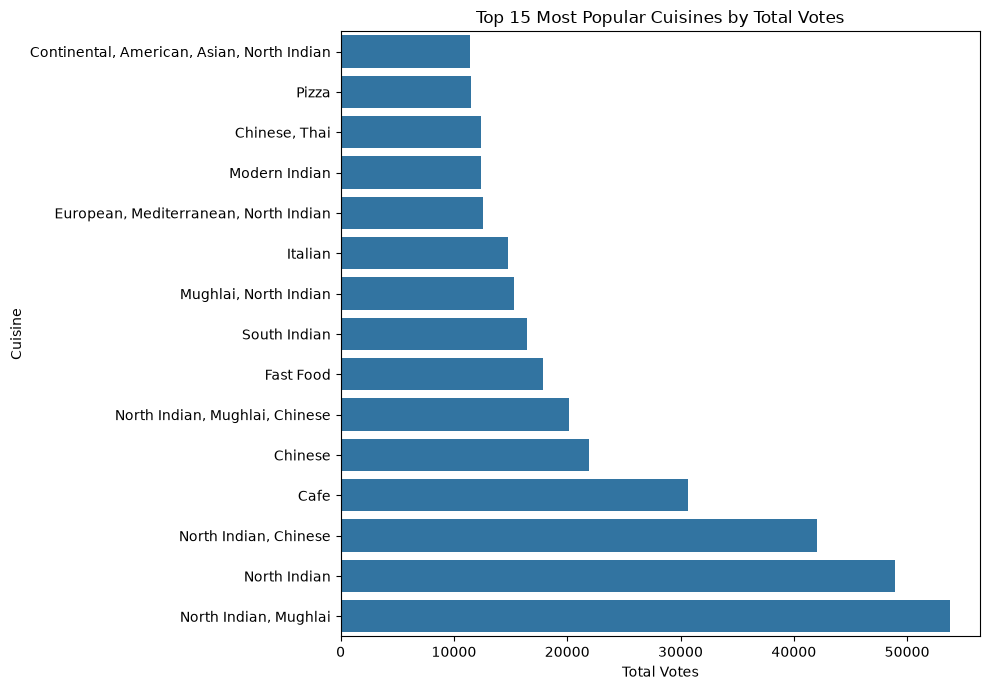

In [9]:
# VISUALIZE MOST POPULAR CUISINES
# ==========================================================

top_voted_cuisines = cuisine_votes.head(15).sort_values(
    by="Total_Votes"
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_voted_cuisines,
    x="Total_Votes",
    y="Cuisines"
)

plt.title("Top 15 Most Popular Cuisines by Total Votes")
plt.xlabel("Total Votes")
plt.ylabel("Cuisine")
plt.tight_layout()
plt.show()

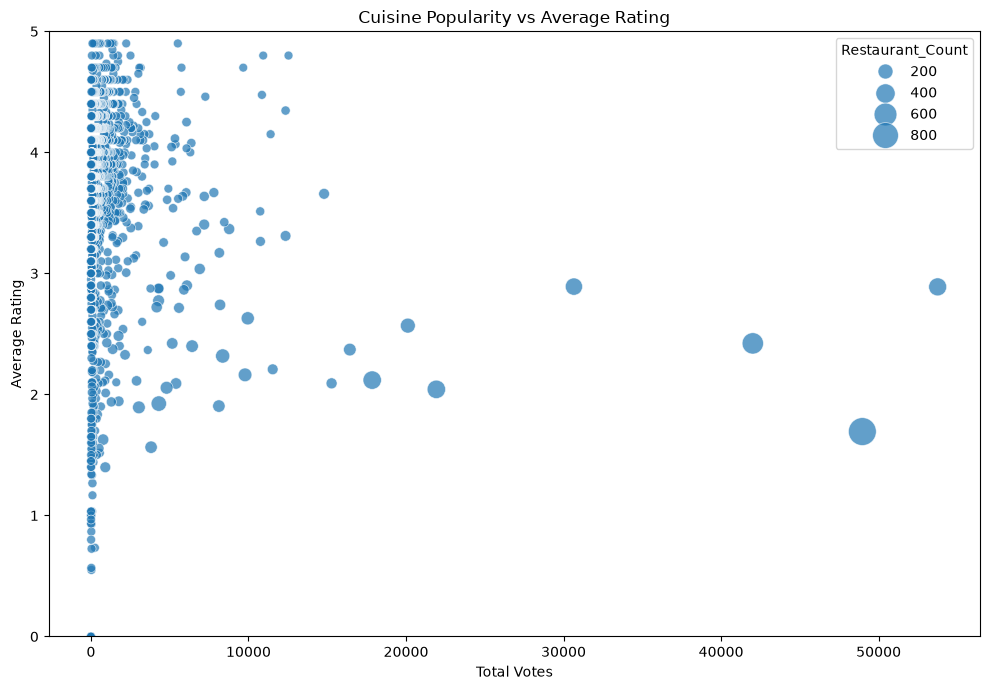

In [10]:
# CUISINE RATING VS TOTAL VOTES
# ==========================================================

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=cuisine_votes,
    x="Total_Votes",
    y="Average_Rating",
    size="Restaurant_Count",
    sizes=(40, 400),
    alpha=0.7
)

plt.title("Cuisine Popularity vs Average Rating")
plt.xlabel("Total Votes")
plt.ylabel("Average Rating")
plt.ylim(0, 5)

plt.tight_layout()
plt.show()

In [11]:
# CUISINE ANALYSIS SUMMARY
# ==========================================================

# Top cuisines by average rating
top_rated = reliable_cuisines.head(10)[
    ["Cuisines", "Average_Rating", "Restaurant_Count", "Total_Votes"]
].copy()

# Top cuisines by total votes
top_popular = cuisine_votes.head(10)[
    ["Cuisines", "Total_Votes", "Restaurant_Count", "Average_Rating"]
].copy()

print("=" * 70)
print("TOP 10 HIGHEST-RATED CUISINES")
print("=" * 70)
display(top_rated)

print("\n" + "=" * 70)
print("TOP 10 MOST POPULAR CUISINES BY TOTAL VOTES")
print("=" * 70)
display(top_popular)

TOP 10 HIGHEST-RATED CUISINES


,Cuisines,Average_Rating,Restaurant_Count,Total_Votes
6,American,3.667742,31,7802
1031,Italian,3.657407,54,14799
1098,"Italian, Pizza",3.637500,24,5828
1212,Mexican,3.636111,36,7193
625,Continental,3.566667,21,3455
837,"Fast Food, Burger",3.403571,56,7189
487,"Cafe, Tea",3.375000,20,2532
191,"Bakery, Desserts, Fast Food",3.366667,63,8775
54,"American, Fast Food",3.350000,20,6708
588,"Chinese, Thai",3.309804,51,12354



TOP 10 MOST POPULAR CUISINES BY TOTAL VOTES


,Cuisines,Total_Votes,Restaurant_Count,Average_Rating
1514,"North Indian, Mughlai",53747,334,2.888623
1306,North Indian,48967,945,1.693228
1329,"North Indian, Chinese",42012,511,2.421722
331,Cafe,30657,299,2.890970
497,Chinese,21925,354,2.042090
1520,"North Indian, Mughlai, Chinese",20115,197,2.568528
828,Fast Food,17852,354,2.118362
1699,South Indian,16433,112,2.370536
1288,"Mughlai, North Indian",15275,60,2.091667
1031,Italian,14799,54,3.657407


In [12]:
#  SAVE TASK 2 ANALYSIS RESULTS
# ==========================================================

# Save cuisine rating analysis
cuisine_rating.to_csv(
    "Outputs/cuisine_rating_analysis.csv",
    index=False
)

# Save cuisine popularity analysis
cuisine_votes.to_csv(
    "Outputs/cuisine_votes_analysis.csv",
    index=False
)

# Save reliable highest-rated cuisines
reliable_cuisines.to_csv(
    "Outputs/highest_rated_cuisines.csv",
    index=False
)

print("Task 2 output files saved successfully!")

print("\nFiles created:")
print("1. Outputs/cuisine_rating_analysis.csv")
print("2. Outputs/cuisine_votes_analysis.csv")
print("3. Outputs/highest_rated_cuisines.csv")

Task 2 output files saved successfully!

Files created:
1. Outputs/cuisine_rating_analysis.csv
2. Outputs/cuisine_votes_analysis.csv
3. Outputs/highest_rated_cuisines.csv


In [13]:
#  KEY FINDINGS
# ==========================================================

# Highest-rated cuisine
best_cuisine = reliable_cuisines.iloc[0]

# Most popular cuisine
most_popular = cuisine_votes.iloc[0]

# Overall cuisine statistics
highest_rating = reliable_cuisines["Average_Rating"].max()
lowest_rating = reliable_cuisines["Average_Rating"].min()

print("=" * 70)
print("KEY FINDINGS - CUSTOMER PREFERENCE ANALYSIS")
print("=" * 70)

print(
    f"\n1. Highest-rated cuisine: {best_cuisine['Cuisines']}"
    f" with an average rating of {best_cuisine['Average_Rating']:.2f}"
    f" across {int(best_cuisine['Restaurant_Count'])} restaurants."
)

print(
    f"\n2. Most popular cuisine by total votes: {most_popular['Cuisines']}"
    f" with {int(most_popular['Total_Votes']):,} total votes."
)

print(
    f"\n3. Highest average cuisine rating among reliable cuisines: "
    f"{highest_rating:.2f}"
)

print(
    f"\n4. Lowest average cuisine rating among reliable cuisines: "
    f"{lowest_rating:.2f}"
)

print(
    "\n5. The analysis shows differences in average ratings across cuisine "
    "types, indicating that cuisine preference can be associated with "
    "restaurant rating."
)

KEY FINDINGS - CUSTOMER PREFERENCE ANALYSIS

1. Highest-rated cuisine: American with an average rating of 3.67 across 31 restaurants.

2. Most popular cuisine by total votes: North Indian, Mughlai with 53,747 total votes.

3. Highest average cuisine rating among reliable cuisines: 3.67

4. Lowest average cuisine rating among reliable cuisines: 1.40

5. The analysis shows differences in average ratings across cuisine types, indicating that cuisine preference can be associated with restaurant rating.


In [14]:
# CONCLUSION
# ==========================================================

print("=" * 70)
print("CONCLUSION - CUSTOMER PREFERENCE ANALYSIS")
print("=" * 70)

print("""
The customer preference analysis examined the relationship between
cuisine types, restaurant ratings, and customer votes.

The analysis identified the most popular cuisines based on total
customer votes and compared the average ratings of different cuisine
categories. Cuisines with at least 20 restaurants were considered
for reliable rating comparisons to reduce the effect of small sample
sizes.

The results show that cuisine categories differ in both customer
engagement and average restaurant ratings. Therefore, cuisine type
can provide useful insights into customer preferences and restaurant
performance.

Overall, the analysis helps identify popular cuisines and cuisine
categories that tend to receive higher ratings, providing useful
information for understanding customer preferences.
""")

CONCLUSION - CUSTOMER PREFERENCE ANALYSIS

The customer preference analysis examined the relationship between
cuisine types, restaurant ratings, and customer votes.

The analysis identified the most popular cuisines based on total
customer votes and compared the average ratings of different cuisine
categories. Cuisines with at least 20 restaurants were considered
for reliable rating comparisons to reduce the effect of small sample
sizes.

The results show that cuisine categories differ in both customer
engagement and average restaurant ratings. Therefore, cuisine type
can provide useful insights into customer preferences and restaurant
performance.

Overall, the analysis helps identify popular cuisines and cuisine
categories that tend to receive higher ratings, providing useful
information for understanding customer preferences.

